In [65]:
# 1. Objectif
# Dans cette section, on finalise le socle du projet en validant :
# - le backtest d'une stratégie optionnelle simple ;
# - sa version delta-hedgée.
# L'objectif n'est pas encore d'étudier les moment swaps, mais de vérifier que le moteur de P&L
# la gestion des positions et le hedge directionnel fonctionnent correctement. 
# Cette étape est essentielle avant de construire des stratégies de variance, gamma ou skew swap.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sys
import os

# ajoute le dossier racine du projet au PYTHONPATH
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

from datetime import datetime
from warnings import filterwarnings

filterwarnings("ignore")
matplotlib.rc("font", **{"size": 14})

from investment_lab.option_trade import OptionTrade, DeltaHedgedOptionTrade
from investment_lab.backtest import StrategyBacktester, BacktesterBidAskFromData
from investment_lab import option_strategies as option_strategies
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio
from investment_lab.data.option_db import OptionLoader
from investment_lab.option_selection import select_closest_maturity
from investment_lab.option_trade import VarianceSwap
from investment_lab.backtest import StrategyBacktester
from investment_lab.data.option_db import extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward

c:\Users\owenm\Documents\M2 Dauphine\S2\Trading de vol\Projet\Dauphine-Lecture-Volatility


On commence par une stratégie simple et standard du cours : un short strangle hebdomadaire sur SPY. On backteste d'abord la stratégie nue, puis sa version delta-hedgée, afin d'isoler l'effet du hedge sur le profil de risque.
La première table de trades correspond à la stratégie non hedgée. La seconde utilise la classe `DeltaHedgedOptionTrade`, qui ajoute automatiquement une jambe de couverture directionnelle. On conserve ici le même sous-jacent, la même fenêtre et les mêmes règles de sélection pour rendre la comparaison propre.

In [67]:
START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2021, 4, 30)
TICKER = "SPY"
LEGS = option_strategies.SHORT_1W_STRANGLE_95_105
df_trades_unhedged = OptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

df_trades_delta_hedged = DeltaHedgedOptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

print("Unhedged trades shape:", df_trades_unhedged.shape)
print("Delta-hedged trades shape:", df_trades_delta_hedged.shape)

df_trades_unhedged.head()

Unhedged trades shape: (2338, 6)
Delta-hedged trades shape: (3507, 6)


,date,option_id,entry_date,leg_name,weight,ticker
0,2020-01-03,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
1,2020-01-03,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
2,2020-01-06,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
3,2020-01-06,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
4,2020-01-06,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY


On lance ensuite le backtest sur les deux portefeuilles. Le `StrategyBacktester` recharge les données nécessaires, calcule le P\&L journalier et construit la NAV. Il fournit aussi une décomposition utile du P\&L, notamment la contribution delta.

In [68]:
bt_unhedged = StrategyBacktester(df_trades_unhedged).compute_backtest()
bt_delta_hedged = StrategyBacktester(df_trades_delta_hedged).compute_backtest()

100%|██████████| 346/346 [00:02<00:00, 160.21it/s]


On résume d'abord les performances globales. Les métriques retenues sont volontairement simples : Sharpe, maximum drawdown et Calmar. Cela suffit ici pour juger l'effet du hedge sur le couple rendement/risque.

In [69]:
def performance_summary(backtests: dict[str, object]) -> pd.DataFrame:
    rows = []
    for name, bt in backtests.items():
        nav = bt.nav["NAV"].copy()
        rets = nav.pct_change().dropna()

        rows.append(
            {
                "Strategy": name,
                "Final NAV": nav.iloc[-1],
                "Sharpe": sharpe_ratio(rets),
                "Max Drawdown (%)": 100 * max_drawdown(rets),
                "Calmar": calmar_ratio(rets),
                "Mean Daily Return": rets.mean(),
                "Daily Vol": rets.std(),
            }
        )

    return pd.DataFrame(rows).set_index("Strategy").sort_index()


summary_df = performance_summary(
    {
        "Short Strangle": bt_unhedged,
        "Short Strangle + Delta Hedge": bt_delta_hedged,
    }
)

summary_df.round(4)

,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean Daily Return,Daily Vol
Strategy,,,,,,
Short Strangle,0.9953,-0.0263,-6.3458,-0.0252,-0.0000,0.0038
Short Strangle + Delta Hedge,1.0988,2.2311,-2.1059,3.2817,0.0003,0.0020


On compare maintenant les courbes de NAV. Si le hedge fonctionne correctement, on s'attend en général à une trajectoire plus régulière et à une réduction des drawdowns directionnels, au prix éventuel d'un rendement moyen plus faible.

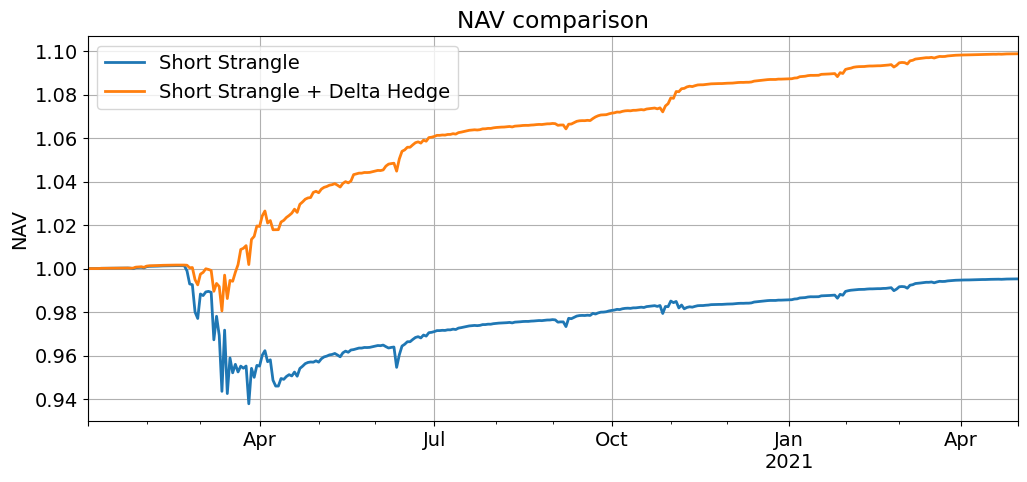

In [70]:
fig, ax = plt.subplots(figsize=(12, 5))

bt_unhedged.nav["NAV"].plot(ax=ax, label="Short Strangle", lw=2)
bt_delta_hedged.nav["NAV"].plot(ax=ax, label="Short Strangle + Delta Hedge", lw=2)

ax.set_title("NAV comparison")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

La décomposition du P\&L est particulièrement utile ici. Pour la stratégie non hedgée, la composante delta doit rester importante. Pour la stratégie hedgée, elle doit être nettement atténuée. On regarde donc le P\&L total et le P\&L hors delta.

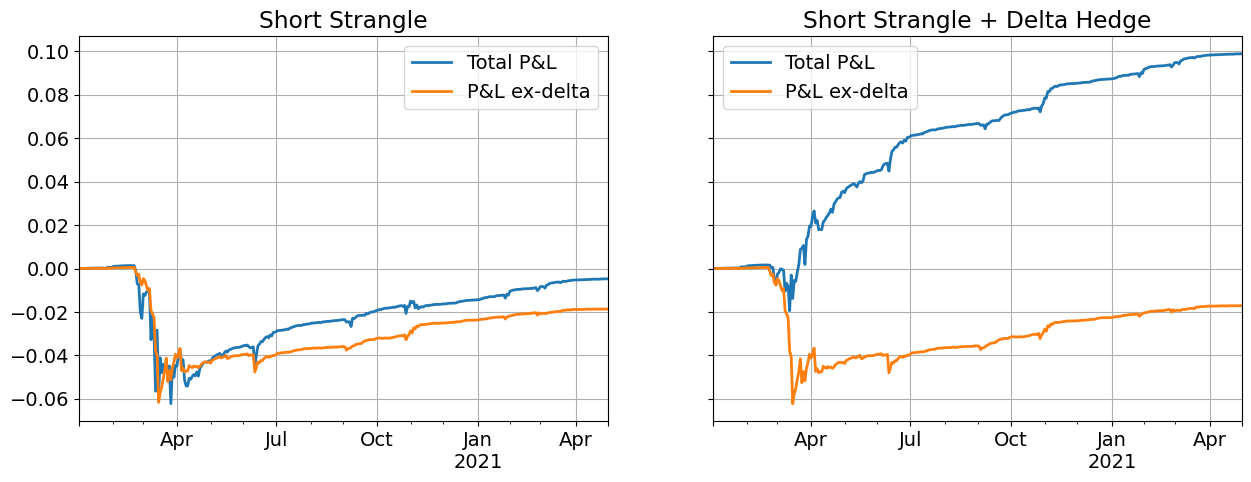

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

(bt_unhedged.pnl["pnl"]).cumsum().plot(ax=axes[0], label="Total P&L", lw=2)
(bt_unhedged.pnl["pnl"] - bt_unhedged.pnl["delta_pnl"]).cumsum().plot(
    ax=axes[0], label="P&L ex-delta", lw=2
)
axes[0].set_title("Short Strangle")
axes[0].grid(True)
axes[0].legend()

(bt_delta_hedged.pnl["pnl"]).cumsum().plot(ax=axes[1], label="Total P&L", lw=2)
(bt_delta_hedged.pnl["pnl"] - bt_delta_hedged.pnl["delta_pnl"]).cumsum().plot(
    ax=axes[1], label="P&L ex-delta", lw=2
)
axes[1].set_title("Short Strangle + Delta Hedge")
axes[1].grid(True)
axes[1].legend()

plt.show()

Un deuxième contrôle utile consiste à regarder l'exposition delta agrégée du portefeuille au cours du temps. On calcule pour cela la somme des deltas pondérés des positions driftées. Une bonne couverture delta doit rendre cette série proche de zéro, ou au moins beaucoup plus faible que celle de la stratégie non hedgée.

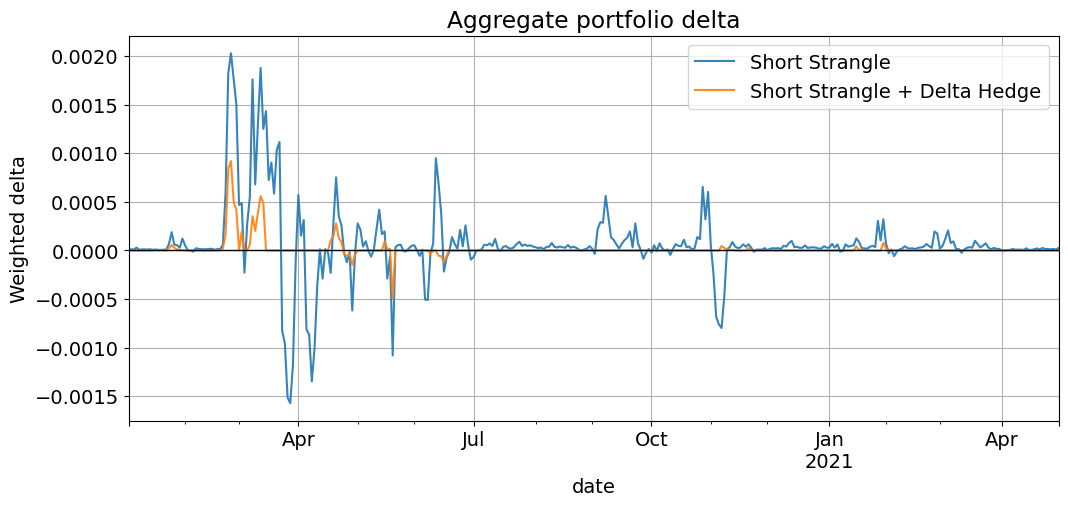

In [72]:
def aggregate_weighted_delta(bt) -> pd.Series:
    df_pos = bt.drifted_positions.copy()
    df_pos["weighted_delta"] = df_pos["delta"] * df_pos["scaled_weight"]
    return df_pos.groupby("date")["weighted_delta"].sum()


delta_exposure_unhedged = aggregate_weighted_delta(bt_unhedged)
delta_exposure_hedged = aggregate_weighted_delta(bt_delta_hedged)

fig, ax = plt.subplots(figsize=(12, 5))
delta_exposure_unhedged.plot(ax=ax, label="Short Strangle", alpha=0.9)
delta_exposure_hedged.plot(ax=ax, label="Short Strangle + Delta Hedge", alpha=0.9)
ax.axhline(0.0, color="black", lw=1)
ax.set_title("Aggregate portfolio delta")
ax.set_ylabel("Weighted delta")
ax.grid(True)
ax.legend()
plt.show()

On résume enfin l'effet du hedge avec deux indicateurs simples :

- l'écart-type de l'exposition delta agrégée ;
- la moyenne absolue de cette exposition.

Ces deux quantités doivent diminuer après hedging.

In [73]:
delta_diag = pd.DataFrame(
    {
        "Std of aggregate delta": [
            delta_exposure_unhedged.std(),
            delta_exposure_hedged.std(),
        ],
        "Mean abs aggregate delta": [
            delta_exposure_unhedged.abs().mean(),
            delta_exposure_hedged.abs().mean(),
        ],
    },
    index=["Short Strangle", "Short Strangle + Delta Hedge"],
)

delta_diag.round(6)

,Std of aggregate delta,Mean abs aggregate delta
Short Strangle,0.000385,0.000177
Short Strangle + Delta Hedge,0.000098,0.000022


À ce stade, on a validé trois points essentiels :

1. le moteur de backtest produit une NAV et un P\&L cohérents ;
2. la couverture delta réduit effectivement l'exposition directionnelle du portefeuille ;
3. la comparaison entre stratégie nue et stratégie hedgée est suffisamment propre pour servir de base au projet.

Cette étape est importante car les stratégies de variance swap, gamma swap et skew swap reposent ensuite sur le même moteur de sélection, de pondération et de backtest.

Comme le delta hedge implique des ajustements plus fréquents, il est naturel de vérifier l'effet des coûts de transaction. On utilise ici le backtester fondé sur les bid-ask observés dans la base.

100%|██████████| 346/346 [00:04<00:00, 71.61it/s]


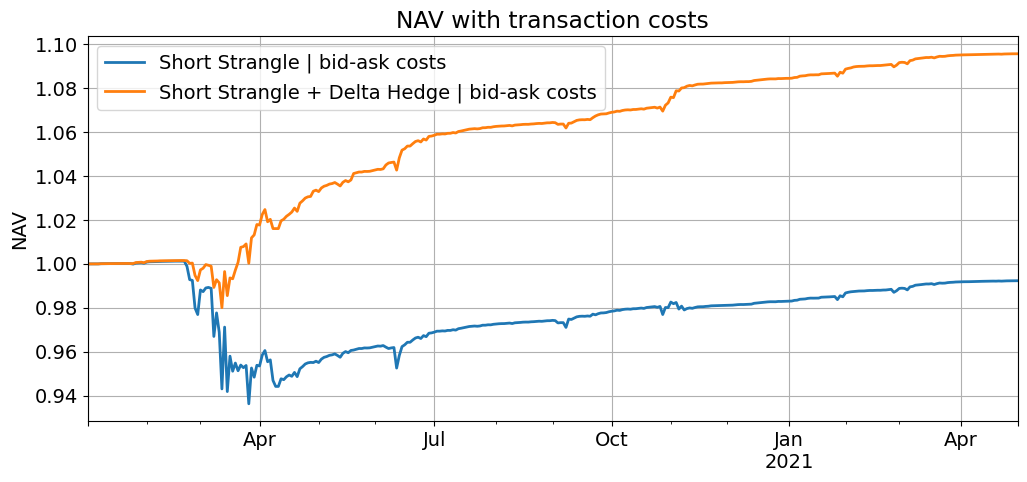

In [74]:
bt_unhedged_tcost = BacktesterBidAskFromData(df_trades_unhedged).compute_backtest()
bt_delta_hedged_tcost = BacktesterBidAskFromData(df_trades_delta_hedged).compute_backtest()

summary_tcost_df = performance_summary(
    {
        "Short Strangle": bt_unhedged_tcost,
        "Short Strangle + Delta Hedge": bt_delta_hedged_tcost,
    }
)

summary_tcost_df.round(4)
fig, ax = plt.subplots(figsize=(12, 5))

bt_unhedged_tcost.nav["NAV"].plot(ax=ax, label="Short Strangle | bid-ask costs", lw=2)
bt_delta_hedged_tcost.nav["NAV"].plot(ax=ax, label="Short Strangle + Delta Hedge | bid-ask costs", lw=2)

ax.set_title("NAV with transaction costs")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

Le delta hedge améliore nettement le contrôle du risque directionnel : l'exposition delta agrégée est plus faible et la trajectoire de P\&L devient moins dépendante des mouvements du sous-jacent. En revanche, cette stabilisation peut s'accompagner d'un coût de portage et, en présence de coûts de transaction, d'une érosion de performance supplémentaire. Cette validation est indispensable avant de passer à des expositions plus structurées, comme la réplication de variance swap, gamma swap et skew swap.

# 2. Réplication d'un gamma swap et construction d'un skew swap

La librairie fournie contient déjà une implémentation de réplication discrète d'un variance swap via un strip d'options OTM. Cette brique servira de point de départ pour construire deux expositions supplémentaires :

- un gamma swap, répliqué par un strip d'options OTM avec une pondération différente ;
- un skew swap, approché comme la différence entre un variance swap et un gamma swap.

Cette approche est directement motivée par la littérature sur les moment swaps et par le résultat pratique selon lequel un skew swap peut être approché par `variance swap - gamma swap`. (Lee)

Pour construire le gamma swap, on repart de la formule théorique de réplication statique. 
Contrairement à une simple pondération heuristique en `dK / K`, on utilise ici :

- une séparation des options OTM autour du forward ;
- la maturité effective \(T\) ;
- le facteur de discounting \(e^{rT}\) ;
- la pondération continue en \(1/K\), discrétisée sur la grille de strikes disponible.

Chargement des données avec forward

In [75]:
def load_option_data_with_forward(start_date, end_date, ticker="SPY"):
    """
    Charge les options et ajoute forward + taux.
    """
    df_options = OptionLoader.load_data(
        start_date,
        end_date,
        process_kwargs={"ticker": ticker},
    ).copy()

    df_rates = USRatesLoader.load_data(start_date, end_date)
    df_options = compute_forward(df_options=df_options, df_rates=df_rates)

    df_options["date"] = pd.to_datetime(df_options["date"])
    return df_options

Sélection du strip OTM autour du forward

In [76]:
def build_otm_strip_forward_based(df_day, day_to_expiry_target=30):
    """
    Sélectionne la maturité la plus proche puis conserve
    les puts OTM (K <= F) et calls OTM (K >= F).
    """
    selected = select_closest_maturity(
        df_day,
        day_to_expiry_target=day_to_expiry_target
    ).copy()

    forward = selected["forward"].iloc[0]

    otm_filter = (
        ((selected["call_put"] == "P") & (selected["strike"] <= forward))
        | ((selected["call_put"] == "C") & (selected["strike"] >= forward))
    )

    selected = selected.loc[otm_filter].copy()
    selected = selected.sort_values("strike")
    return selected

La discrétisation du strip est un point important. Comme en pratique on ne dispose que d'une grille finie de strikes, on remplace l'intégrale continue par une somme discrète pondérée par des écarts de strike `dK`. Cette étape est nécessaire à la fois pour le variance swap et pour le gamma swap.

In [77]:
def add_discrete_dk(df_strip):
    """
    Approximation discrète de dK sur une grille de strikes.
    """
    df_strip = df_strip.sort_values("strike").copy()

    prev_k = df_strip["strike"].shift(1)
    next_k = df_strip["strike"].shift(-1)

    dk_center = (next_k - prev_k) / 2.0
    dk_forward = next_k - df_strip["strike"]
    dk_backward = df_strip["strike"] - prev_k

    df_strip["dK"] = dk_center
    df_strip.loc[df_strip["dK"].isna(), "dK"] = dk_forward
    df_strip.loc[df_strip["dK"].isna(), "dK"] = dk_backward

    return df_strip

Poids théoriques du gamma swap

Ici, on utilise la formule discrète cohérente avec le strike du gamma swap : FORMULE A RENTRER 

Le facteur commun est important si on veut comparer ensuite variance, gamma et skew sur une base plus économique.

In [115]:
def build_gamma_swap_weights_for_date(df_day, day_to_expiry_target=30, weight_sign=-1.0):
    """
    Construit les poids d'un gamma swap à partir de la formule théorique :
        2 * exp(rT) / (T * S0) * dK / K
    """
    strip_df = build_otm_strip_forward_based(
        df_day=df_day,
        day_to_expiry_target=day_to_expiry_target
    )
    strip_df = add_discrete_dk(strip_df)

    spot = strip_df["spot"].iloc[0]
    r = strip_df["risk_free_rate"].iloc[0]
    T = strip_df["day_to_expiration"].iloc[0] / 365.25

    strip_df["raw_weight"] = (
    weight_sign
    * 2.0
    * np.exp(r * T)
    / (T * spot)
    * strip_df["dK"]
    / strip_df["strike"]
)

    strip_df["mid"] = (strip_df["bid"] + strip_df["ask"]) / 2

    premium = (strip_df["raw_weight"] * strip_df["mid"]).sum()

    strip_df["weight"] = strip_df["raw_weight"] / abs(premium)

    strip_df["trade_type"] = "GammaSwapCustom"
    strip_df["leg_name"] = "Gamma Swap OTM strip"
    strip_df["entry_date"] = strip_df["date"]

    return strip_df

On génère maintenant une série temporelle de portefeuilles gamma swap. Chaque date d'entrée correspond à une date de rebalancement, et chaque portefeuille est constitué d'un strip d'options OTM à maturité cible.

In [116]:
def generate_gamma_swap_trades(
    start_date,
    end_date,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
):
    """
    Génère une série de portefeuilles gamma swap
    compatibles avec le backtester existant.
    """
    df_options = load_option_data_with_forward(start_date, end_date, ticker=ticker)

    rebal_dates = sorted(
        df_options.loc[df_options["date"].dt.weekday == rebal_week_day, "date"].unique()
    )

    trades = []

    for dt in rebal_dates:
        df_day = df_options.loc[df_options["date"] == dt].copy()
        if df_day.empty:
            continue

        try:
            gamma_df = build_gamma_swap_weights_for_date(
                df_day=df_day,
                day_to_expiry_target=day_to_expiry_target,
                weight_sign=weight_sign,
            )
            trades.append(gamma_df)
        except Exception:
            continue

    if not trades:
        raise ValueError("Aucun trade gamma swap n'a pu être généré.")

    gamma_trades = pd.concat(trades, ignore_index=True)
    return gamma_trades 

In [117]:
START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2022, 4, 30)

df_options_fw = load_option_data_with_forward(START_DATE, END_DATE, ticker="SPY")
one_day = df_options_fw.loc[df_options_fw["date"] == pd.Timestamp("2020-01-08")].copy()

gamma_one_day = build_gamma_swap_weights_for_date(
    df_day=one_day,
    day_to_expiry_target=30,
    weight_sign=-1.0,
)

gamma_one_day[["strike", "call_put", "spot", "forward", "dK", "weight"]].head(20)

,strike,call_put,spot,forward,dK,weight
72,270.0,P,324.39,324.789905,5.00,-0.077411
73,275.0,P,324.39,324.789905,5.00,-0.076004
74,280.0,P,324.39,324.789905,3.75,-0.055985
75,282.5,P,324.39,324.789905,2.50,-0.036993
76,285.0,P,324.39,324.789905,2.50,-0.036669
77,287.5,P,324.39,324.789905,2.50,-0.036350
78,290.0,P,324.39,324.789905,2.50,-0.036036
79,292.5,P,324.39,324.789905,2.50,-0.035728
80,295.0,P,324.39,324.789905,2.50,-0.035426
81,297.5,P,324.39,324.789905,2.50,-0.035128


Avant le backtest, on vérifie les poids sur une date donnée. Cette étape permet de contrôler que :

- la séparation puts/calls est bien faite autour du forward ;
- les poids décroissent correctement avec le strike selon une pondération en \(1/K\) ;
- les ordres de grandeur sont cohérents.

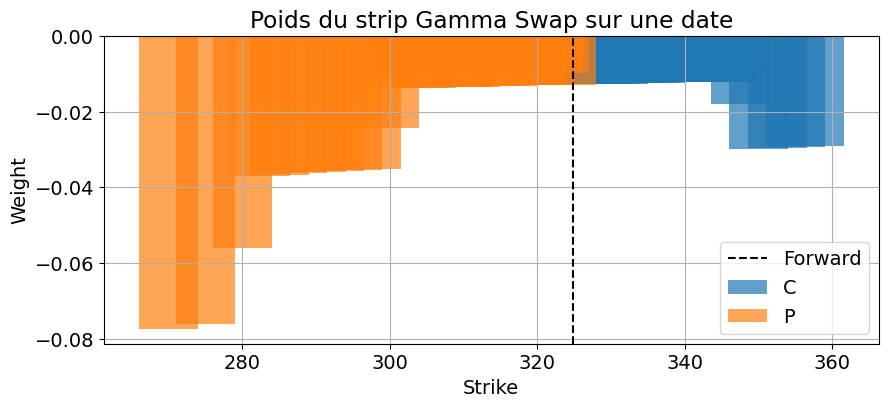

100%|██████████| 603/603 [00:05<00:00, 113.00it/s]


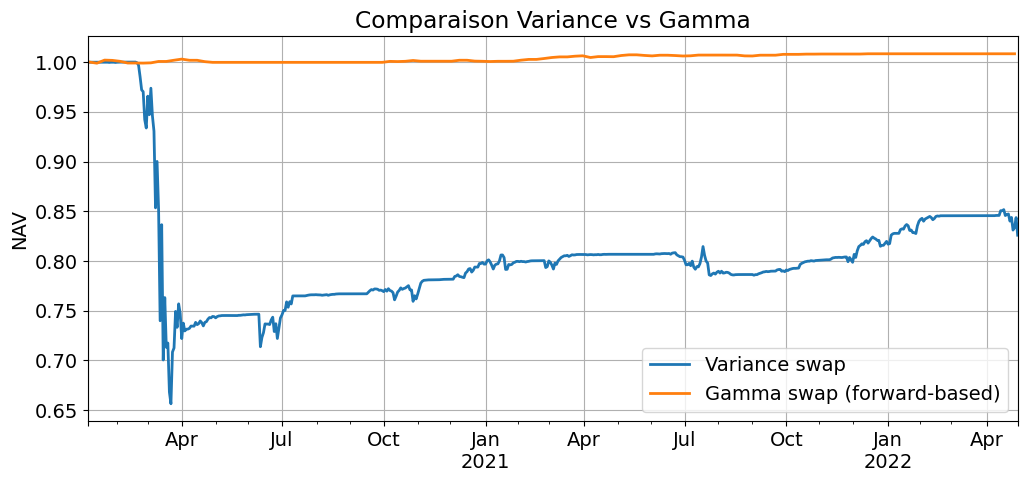

In [118]:
fig, ax = plt.subplots(figsize=(10, 4))

for cp, g in gamma_one_day.groupby("call_put"):
    ax.bar(
        g["strike"],
        g["weight"],
        width=8,
        alpha=0.7,
        label=f"{cp}"
    )

ax.axvline(gamma_one_day["forward"].iloc[0], color="black", linestyle="--", label="Forward")
ax.set_title("Poids du strip Gamma Swap sur une date")
ax.set_xlabel("Strike")
ax.set_ylabel("Weight")
ax.grid(True)
ax.legend()
plt.show()

gamma_trades_fw = generate_gamma_swap_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

bt_gamma_fw = StrategyBacktester(gamma_trades_fw).compute_backtest()

bt_variance = StrategyBacktester(variance_trades).compute_backtest()

fig, ax = plt.subplots(figsize=(12, 5))

bt_variance.nav["NAV"].plot(ax=ax, label="Variance swap", lw=2)
bt_gamma_fw.nav["NAV"].plot(ax=ax, label="Gamma swap (forward-based)", lw=2)

ax.set_title("Comparaison Variance vs Gamma")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

100%|██████████| 121/121 [00:00<00:00, 140.42it/s]


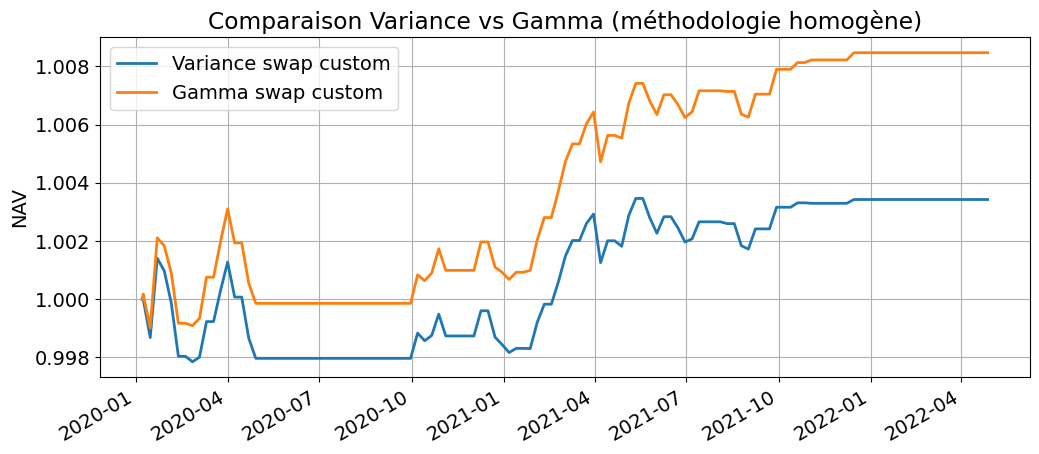

In [119]:
def build_variance_swap_weights_for_date(df_day, day_to_expiry_target=30, weight_sign=-1.0):
    """
    Construit les poids d'un variance swap à partir de la formule théorique :
        2 * exp(rT) / T * dK / K^2
    """
    strip_df = build_otm_strip_forward_based(
        df_day=df_day,
        day_to_expiry_target=day_to_expiry_target
    )
    strip_df = add_discrete_dk(strip_df)

    r = strip_df["risk_free_rate"].iloc[0]
    T = strip_df["day_to_expiration"].iloc[0] / 365.25

    strip_df["raw_weight"] = (
        weight_sign
        * 2.0
        * np.exp(r * T)
        / T
        * strip_df["dK"]
        / (strip_df["strike"] ** 2)
    )

    # normalisation par la prime
    strip_df["mid"] = (strip_df["bid"] + strip_df["ask"]) / 2

    premium = (strip_df["raw_weight"] * strip_df["mid"]).sum()

    strip_df["weight"] = strip_df["raw_weight"] / abs(premium)

    strip_df["trade_type"] = "VarianceSwapCustom"
    strip_df["leg_name"] = "Variance Swap OTM strip"
    strip_df["entry_date"] = strip_df["date"]

    return strip_df

def generate_variance_swap_trades_custom(
    start_date,
    end_date,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
):
    df_options = load_option_data_with_forward(start_date, end_date, ticker=ticker)

    rebal_dates = sorted(
        df_options.loc[df_options["date"].dt.weekday == rebal_week_day, "date"].unique()
    )

    trades = []

    for dt in rebal_dates:
        df_day = df_options.loc[df_options["date"] == dt].copy()
        if df_day.empty:
            continue

        try:
            var_df = build_variance_swap_weights_for_date(
                df_day=df_day,
                day_to_expiry_target=day_to_expiry_target,
                weight_sign=weight_sign,
            )
            trades.append(var_df)
        except Exception:
            continue

    if not trades:
        raise ValueError("Aucun trade variance swap custom n'a pu être généré.")

    return pd.concat(trades, ignore_index=True)

variance_trades_custom = generate_variance_swap_trades_custom(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

gamma_trades_custom = generate_gamma_swap_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

bt_variance_custom = StrategyBacktester(variance_trades_custom).compute_backtest()
bt_gamma_custom = StrategyBacktester(gamma_trades_custom).compute_backtest()

fig, ax = plt.subplots(figsize=(12, 5))

bt_variance_custom.nav["NAV"].plot(ax=ax, label="Variance swap custom", lw=2)
bt_gamma_custom.nav["NAV"].plot(ax=ax, label="Gamma swap custom", lw=2)

ax.set_title("Comparaison Variance vs Gamma (méthodologie homogène)")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

La réplication du variance swap fournie par la librairie ne conserve pas directement toutes les colonnes de marché utiles à l'analyse, comme le prix, la vega ou les autres grecques.

Pour comparer proprement la réplication du variance swap à celle du gamma swap, on enrichit donc la table des trades par fusion avec la base d'options initiale. Cette étape permet de récupérer les variables de marché nécessaires pour analyser la taille économique des positions, leur prime initiale et leurs sensibilités.

## Construction du skew swap

Dans la littérature sur les moment swaps, le skew swap peut être approché comme la différence entre un variance swap et un gamma swap.

On construit donc ici un portefeuille de skew swap en combinant directement les deux réplications précédentes, sans modifier les fichiers source fournis. Cette construction permet d'obtenir une exposition empirique à l'asymétrie de la distribution des rendements à partir d'options vanilles.

In [120]:
def build_skew_swap_trades_custom(variance_trades_df, gamma_trades_df):
    var_df = variance_trades_df.copy()
    gam_df = gamma_trades_df.copy()

    gam_df["weight"] = -gam_df["weight"]

    common_cols = sorted(set(var_df.columns).intersection(set(gam_df.columns)))
    return pd.concat([var_df[common_cols], gam_df[common_cols]], ignore_index=True)
skew_trades_custom = build_skew_swap_trades_custom(
    variance_trades_custom,
    gamma_trades_custom,
)

bt_skew_custom = StrategyBacktester(skew_trades_custom).compute_backtest()

100%|██████████| 121/121 [00:00<00:00, 129.40it/s]


100%|██████████| 121/121 [00:00<00:00, 147.09it/s]


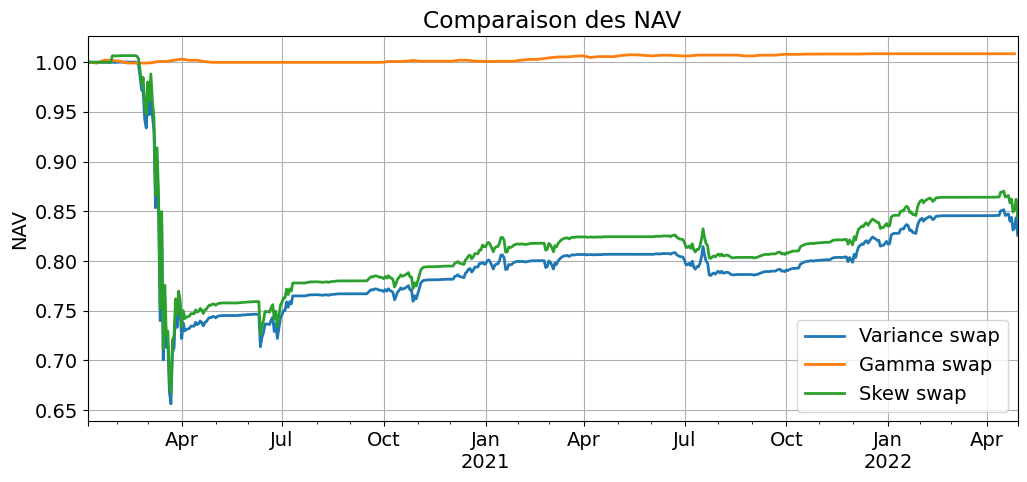

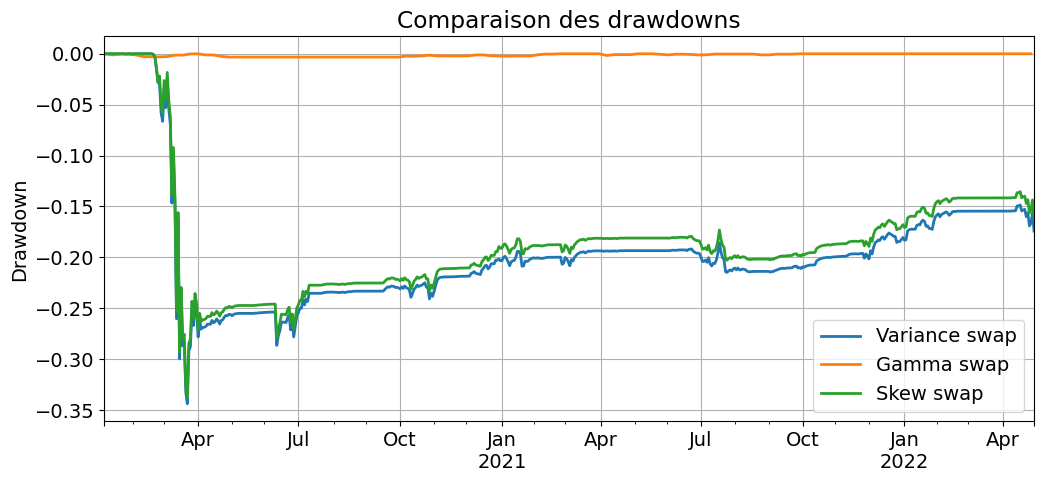

,variance,gamma,skew
variance,1.000000,-0.196745,0.999422
gamma,-0.196745,1.000000,-0.202750
skew,0.999422,-0.202750,1.000000


In [121]:
bt_variance = StrategyBacktester(variance_trades).compute_backtest()
bt_gamma_fw = StrategyBacktester(gamma_trades_fw).compute_backtest()

fig, ax = plt.subplots(figsize=(12, 5))

bt_variance.nav["NAV"].plot(ax=ax, label="Variance swap", lw=2)
bt_gamma_fw.nav["NAV"].plot(ax=ax, label="Gamma swap", lw=2)
bt_skew.nav["NAV"].plot(ax=ax, label="Skew swap", lw=2)

ax.set_title("Comparaison des NAV")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

perf_swaps_df = pd.DataFrame({
    "Variance swap": compute_perf(bt_variance),
    "Gamma swap": compute_perf(bt_gamma_fw),
    "Skew swap": compute_perf(bt_skew),
}).T

perf_swaps_df.round(4)

dd_variance = compute_drawdown(bt_variance.nav["NAV"])
dd_gamma = compute_drawdown(bt_gamma_fw.nav["NAV"])
dd_skew = compute_drawdown(bt_skew.nav["NAV"])

fig, ax = plt.subplots(figsize=(12, 5))

dd_variance.plot(ax=ax, label="Variance swap", lw=2)
dd_gamma.plot(ax=ax, label="Gamma swap", lw=2)
dd_skew.plot(ax=ax, label="Skew swap", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()
plt.show()

rets_variance = bt_variance.nav["NAV"].pct_change().dropna()
rets_gamma = bt_gamma_fw.nav["NAV"].pct_change().dropna()
rets_skew = bt_skew.nav["NAV"].pct_change().dropna()

corr_swaps_df = pd.concat(
    [rets_variance, rets_gamma, rets_skew],
    axis=1
)
corr_swaps_df.columns = ["variance", "gamma", "skew"]

corr_swaps_df.corr()

In [122]:
def compute_average_abs_entry_premium(trades_df):
    """
    Calcule la prime absolue moyenne du portefeuille à la date d'entrée :
        sum_i weight_i * mid_i
    """
    entry_premium_by_date = trades_df.groupby("date").apply(
        lambda df: (df["weight"] * df["mid"]).sum()
    )
    return entry_premium_by_date.abs().mean(), entry_premium_by_date


def build_skew_swap_trades_custom(
    variance_trades_df,
    gamma_trades_df,
    gamma_scale,
):
    """
    Construit un skew swap empirique :
        Skew ≈ Variance - c * Gamma
    avec c choisi pour rendre la jambe gamma comparable en taille économique.
    """
    var_df = variance_trades_df.copy()
    gam_df = gamma_trades_df.copy()

    gam_df["weight"] = -gamma_scale * gam_df["weight"]

    var_df["trade_type"] = "Variance_leg"
    gam_df["trade_type"] = "Scaled_minus_Gamma_leg"

    common_cols = sorted(set(var_df.columns).intersection(set(gam_df.columns)))
    skew_trades_df = pd.concat(
        [var_df[common_cols], gam_df[common_cols]],
        ignore_index=True
    )

    return skew_trades_df

In [123]:
avg_abs_premium_var, premium_var_by_date = compute_average_abs_entry_premium(variance_trades_custom)
avg_abs_premium_gamma, premium_gamma_by_date = compute_average_abs_entry_premium(gamma_trades_custom)

gamma_scale = avg_abs_premium_var / avg_abs_premium_gamma

print(f"Average abs premium | Variance custom : {avg_abs_premium_var:.6f}")
print(f"Average abs premium | Gamma custom    : {avg_abs_premium_gamma:.6f}")
print(f"Gamma normalization factor c          : {gamma_scale:.6f}")

Average abs premium | Variance custom : 0.991736
Average abs premium | Gamma custom    : 0.991736
Gamma normalization factor c          : 1.000000


In [124]:
skew_trades_custom = build_skew_swap_trades_custom(
    variance_trades_df=variance_trades_custom,
    gamma_trades_df=gamma_trades_custom,
    gamma_scale=gamma_scale,
)

bt_skew_custom = StrategyBacktester(skew_trades_custom).compute_backtest()

100%|██████████| 121/121 [00:01<00:00, 106.62it/s]


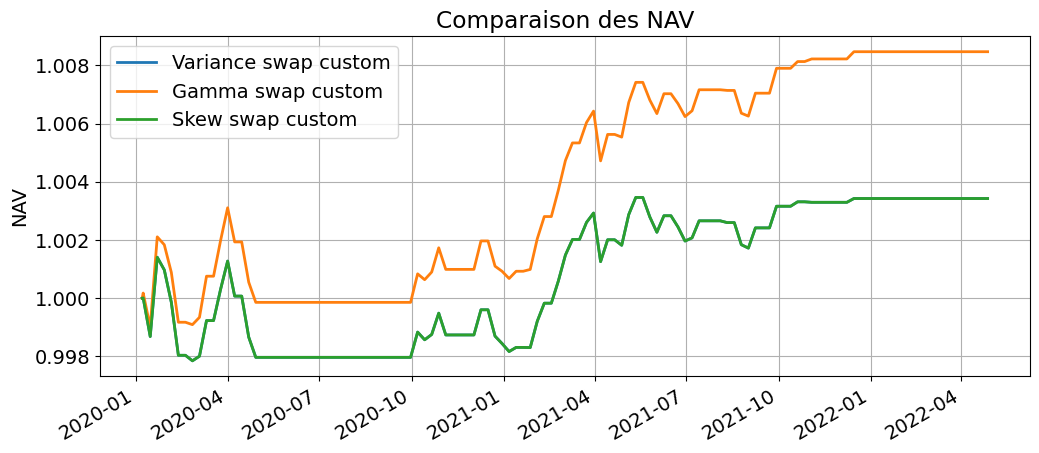

In [125]:
fig, ax = plt.subplots(figsize=(12, 5))

bt_variance_custom.nav["NAV"].plot(ax=ax, label="Variance swap custom", lw=2)
bt_gamma_custom.nav["NAV"].plot(ax=ax, label="Gamma swap custom", lw=2)
bt_skew_custom.nav["NAV"].plot(ax=ax, label="Skew swap custom", lw=2)

ax.set_title("Comparaison des NAV")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

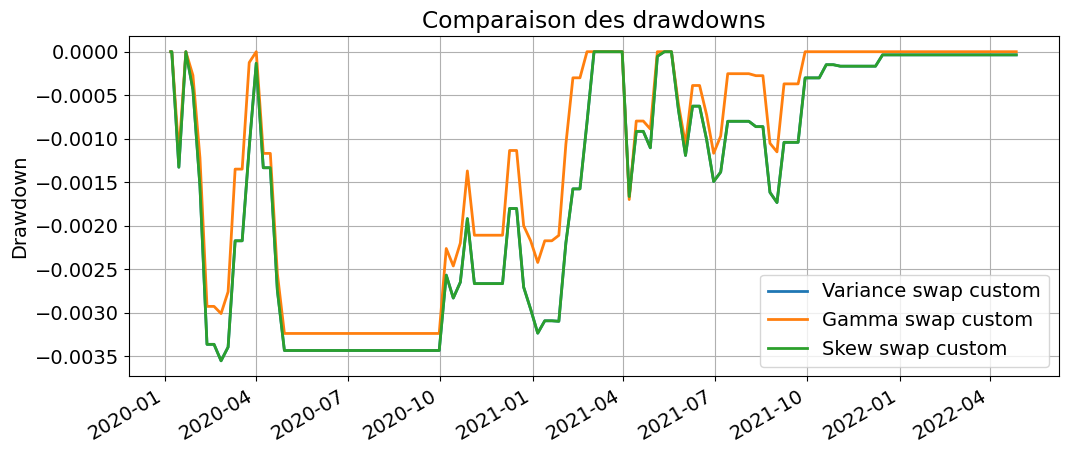

In [126]:
dd_variance_custom = compute_drawdown(bt_variance_custom.nav["NAV"])
dd_gamma_custom = compute_drawdown(bt_gamma_custom.nav["NAV"])
dd_skew_custom = compute_drawdown(bt_skew_custom.nav["NAV"])

fig, ax = plt.subplots(figsize=(12, 5))

dd_variance_custom.plot(ax=ax, label="Variance swap custom", lw=2)
dd_gamma_custom.plot(ax=ax, label="Gamma swap custom", lw=2)
dd_skew_custom.plot(ax=ax, label="Skew swap custom", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()
plt.show()

In [127]:
perf_swaps_custom_df = pd.DataFrame({
    "Variance swap custom": compute_perf(bt_variance_custom),
    "Gamma swap custom": compute_perf(bt_gamma_custom),
    "Skew swap custom": compute_perf(bt_skew_custom),
}).T

perf_swaps_custom_df.round(4)

,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean daily return,Daily vol
Variance swap custom,1.0034,0.8155,-0.3556,2.0144,0.0000,0.0006
Gamma swap custom,1.0085,1.8937,-0.3241,5.4353,0.0001,0.0006
Skew swap custom,1.0034,0.8155,-0.3556,2.0144,0.0000,0.0006


In [128]:
rets_variance_custom = bt_variance_custom.nav["NAV"].pct_change().dropna()
rets_gamma_custom = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew_custom = bt_skew_custom.nav["NAV"].pct_change().dropna()

corr_swaps_custom_df = pd.concat(
    [rets_variance_custom, rets_gamma_custom, rets_skew_custom],
    axis=1
)
corr_swaps_custom_df.columns = ["variance", "gamma", "skew"]

corr_swaps_custom_df.corr()

,variance,gamma,skew
variance,1.000000,0.995411,1.000000
gamma,0.995411,1.000000,0.995411
skew,1.000000,0.995411,1.000000


Dans la réplication discrète utilisée ici, le gamma swap apparaît très proche du variance swap. 

Cette propriété s'explique directement par les formules de réplication :

Variance swap :
w(K) ∝ 1 / K²

Gamma swap :
w(K) ∝ 1 / (S₀ K)

Les deux portefeuilles deviennent très similaires lorsque les strikes du strip restent proches du niveau du spot, car K ≈ S₀ implique :

w_gamma(K) ≈ w_variance(K)

Dans notre implémentation empirique, les options disponibles restent relativement proches du forward, ce qui explique la forte corrélation observée entre les deux stratégies.

## Extension : kurtosis swap

Pour compléter l'étude des moment swaps, on ajoute une mesure empirique du swap de kurtosis, correspondant au moment réalisé d'ordre 4 des log-returns.

Suivant la définition générale des moment swaps, on considère ici le payoff discret :

\[
\text{MOMS}^{(4)} = \sum_{i=1}^{n} \left(\log\frac{S_i}{S_{i-1}}\right)^4
\]

Cette section propose une implémentation empirique du payoff réalisé, à partir des rendements observés du sous-jacent. Contrairement au variance swap et au gamma swap, on ne cherche pas ici à reconstruire une réplication complète par strip d'options vanilles dans le framework existant.

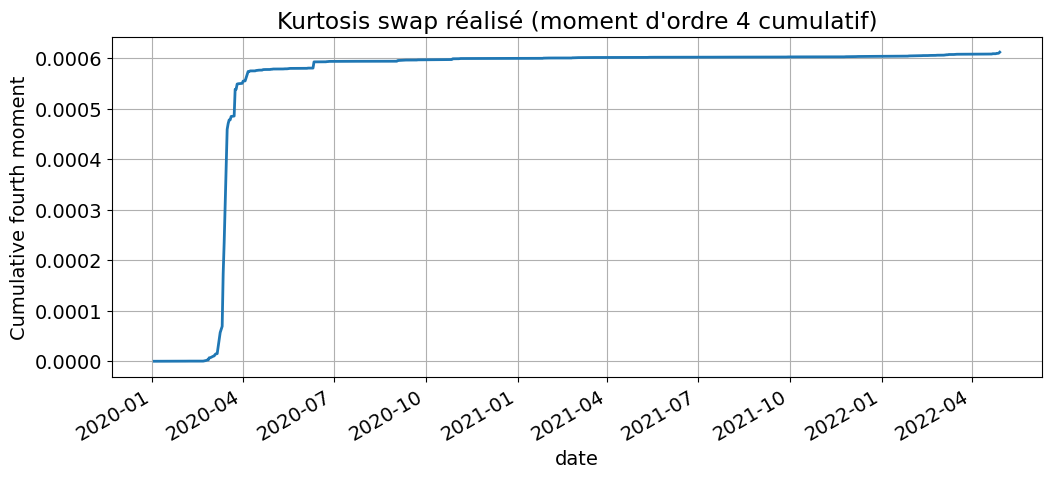

In [129]:
from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.metrics.util import levels_to_returns

def load_spot_series(start_date, end_date, ticker="SPY"):
    """
    Charge la série spot quotidienne à partir de la base d'options.
    """
    df_options = OptionLoader.load_data(
        start_date,
        end_date,
        process_kwargs={"ticker": ticker},
    ).copy()

    df_spot = extract_spot_from_options(df_options).copy()
    df_spot["date"] = pd.to_datetime(df_spot["date"])
    df_spot = df_spot.sort_values("date").drop_duplicates("date")
    return df_spot

def compute_realized_moment_swap(df_spot, order=4, annualize=True, trading_days=252):
    """
    Calcule le payoff réalisé d'un moment swap d'ordre `order`
    à partir des log-returns quotidiens.

    Si annualize=True, on multiplie par 252 / window_length
    dans le cas rolling ; ici en série cumulée simple on conserve
    la somme cumulée des puissances de log-returns.
    """
    df = df_spot.copy()
    df["log_return"] = np.log(df["spot"] / df["spot"].shift(1))
    df[f"moment_{order}"] = df["log_return"] ** order
    return df

df_spot = load_spot_series(START_DATE, END_DATE, ticker="SPY")
df_kurtosis = compute_realized_moment_swap(df_spot, order=4)

df_kurtosis[["date", "spot", "log_return", "moment_4"]].head()

fig, ax = plt.subplots(figsize=(12, 5))

df_kurtosis.set_index("date")["moment_4"].cumsum().plot(ax=ax, lw=2)

ax.set_title("Kurtosis swap réalisé (moment d'ordre 4 cumulatif)")
ax.set_ylabel("Cumulative fourth moment")
ax.grid(True)
plt.show()

Version Rolling

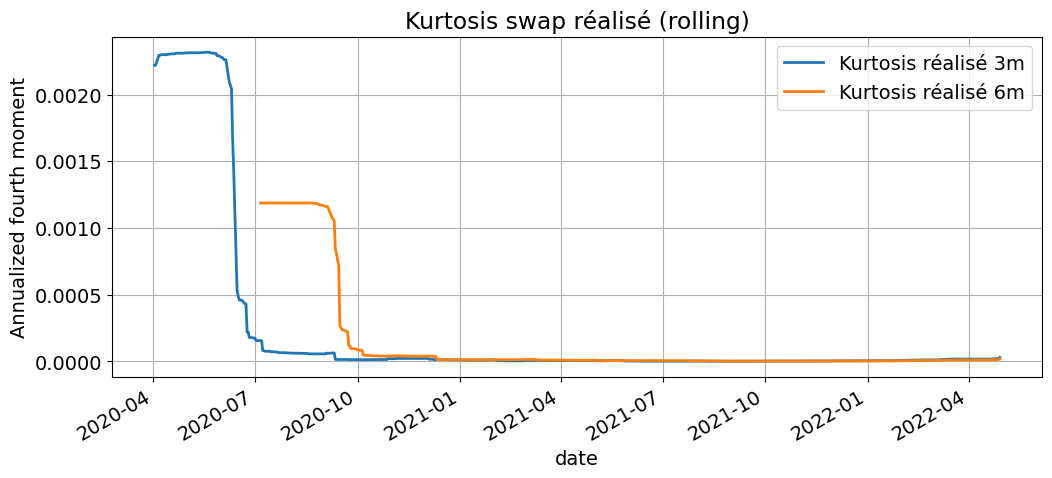

In [130]:
def compute_rolling_realized_moment(df_spot, order=4, window=63, annualize=True, trading_days=252):
    """
    Calcule un moment réalisé rolling d'ordre `order`.
    Exemple :
    - window=63  ~ 3 mois
    - window=126 ~ 6 mois
    """
    df = df_spot.copy()
    df["log_return"] = np.log(df["spot"] / df["spot"].shift(1))
    df[f"moment_{order}"] = df["log_return"] ** order

    rolling = df[f"moment_{order}"].rolling(window).sum()

    if annualize:
        rolling = rolling * (trading_days / window)

    out = pd.DataFrame({
        "date": df["date"],
        f"realized_moment_{order}_{window}d": rolling
    })
    return out

kurt_3m = compute_rolling_realized_moment(df_spot, order=4, window=63)
kurt_6m = compute_rolling_realized_moment(df_spot, order=4, window=126)

fig, ax = plt.subplots(figsize=(12, 5))

kurt_3m.set_index("date").iloc[:, 0].plot(ax=ax, label="Kurtosis réalisé 3m", lw=2)
kurt_6m.set_index("date").iloc[:, 0].plot(ax=ax, label="Kurtosis réalisé 6m", lw=2)

ax.set_title("Kurtosis swap réalisé (rolling)")
ax.set_ylabel("Annualized fourth moment")
ax.grid(True)
ax.legend()
plt.show()

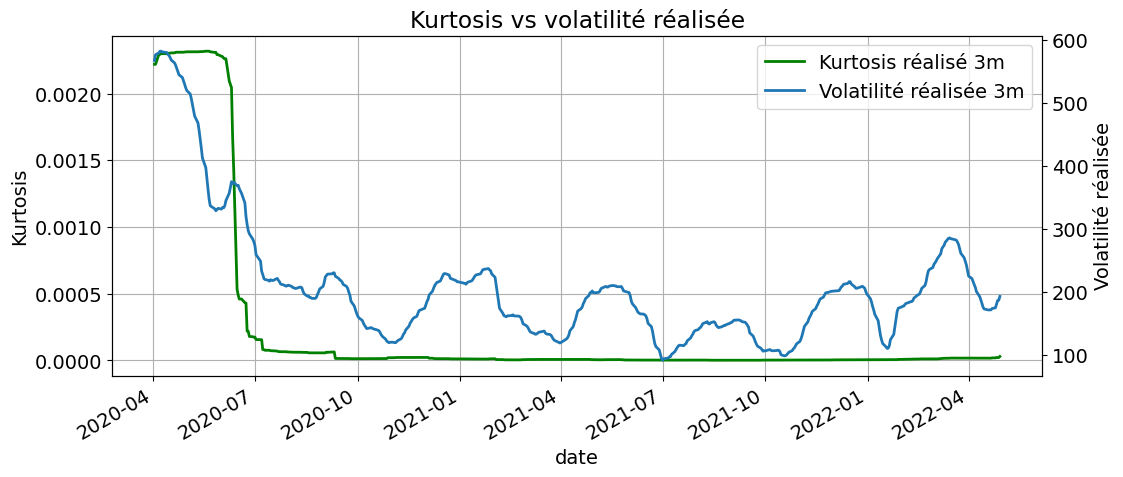

,variance,gamma,skew,kurtosis_change
variance,1.000000,0.996184,1.000000,0.005347
gamma,0.996184,1.000000,0.996184,0.015224
skew,1.000000,0.996184,1.000000,0.005347
kurtosis_change,0.005347,0.015224,0.005347,1.000000


In [137]:
from investment_lab.metrics.volatility import rolling_realized_volatility

df_spot_k = df_spot.copy()
df_spot_k["date"] = pd.to_datetime(df_spot_k["date"])

rv_3m = rolling_realized_volatility(
    df_spot_k.set_index("date")["spot"],
    window=63,
    volatility_type='std'
).rename("realized_vol_3m")

compare_df = pd.concat(
    [
        kurt_3m.set_index("date").iloc[:, 0],
        rv_3m
    ],
    axis=1
).dropna()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

compare_df.iloc[:, 0].plot(ax=ax1, label="Kurtosis réalisé 3m", lw=2, color="green")
compare_df.iloc[:, 1].plot(ax=ax2, label="Volatilité réalisée 3m", lw=2)

ax1.set_title("Kurtosis vs volatilité réalisée")
ax1.set_ylabel("Kurtosis")
ax2.set_ylabel("Volatilité réalisée")
ax1.grid(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

rets_variance_custom = bt_variance_custom.nav["NAV"].pct_change().dropna()
rets_gamma_custom = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew_custom = bt_skew_custom.nav["NAV"].pct_change().dropna()

kurtosis_changes = kurt_3m.set_index("date").iloc[:, 0].diff()

corr_moment_df = pd.concat(
    [
        rets_variance_custom,
        rets_gamma_custom,
        rets_skew_custom,
        kurtosis_changes
    ],
    axis=1
).dropna()

corr_moment_df.columns = ["variance", "gamma", "skew", "kurtosis_change"]
corr_moment_df.corr()

## Analyse du moment swap d'ordre 4 (kurtosis)

Afin de compléter l'analyse des moment swaps, nous étudions ici le moment réalisé d'ordre 4 des log-returns, souvent appelé *kurtosis swap*. Alors que le variance swap capture le second moment des rendements (la volatilité réalisée), le kurtosis swap mesure la fréquence et l'intensité des événements extrêmes dans la distribution des rendements.

### Définition

Le moment réalisé d'ordre 4 est défini par :

\[
M^{(4)} = \sum_{t=1}^{n} \left(\log \frac{S_t}{S_{t-1}}\right)^4
\]

Contrairement au variance swap, cette quantité amplifie fortement les rendements extrêmes puisque les variations sont élevées à la puissance quatre. Ainsi, les chocs de marché dominent largement cette mesure.

---

### Kurtosis swap cumulé

Le premier graphique représente la somme cumulée du moment d'ordre 4. On observe une forte augmentation durant la période de stress du marché au début de l'année 2020, correspondant à la crise du COVID-19. Cette phase est caractérisée par des mouvements de marché très violents, qui contribuent fortement au moment d'ordre 4.

Après cet épisode, la courbe devient presque plate. Cela signifie que les rendements extrêmes deviennent beaucoup plus rares et que la contribution marginale au moment d'ordre 4 est faible.

---

### Kurtosis réalisé rolling

Afin d'obtenir une mesure plus dynamique, nous calculons ensuite un kurtosis réalisé sur des fenêtres glissantes de trois et six mois. Cette approche permet d'observer l'évolution locale du moment d'ordre 4 dans le temps.

Les résultats montrent que le kurtosis réalisé est extrêmement élevé durant les premières phases de la crise de 2020, puis diminue rapidement lorsque le marché se stabilise. Contrairement à la volatilité réalisée, le kurtosis retombe très rapidement après l'épisode de stress.

Cela illustre une propriété importante : les moments d'ordre élevé capturent principalement les événements extrêmes et non les fluctuations normales du marché.

---

### Comparaison avec la volatilité réalisée

Le dernier graphique compare le kurtosis réalisé à la volatilité réalisée sur une fenêtre similaire. On observe que les deux mesures réagissent fortement lors du choc de marché de 2020. Cependant, leurs dynamiques diffèrent ensuite.

La volatilité réalisée reste relativement persistante et présente plusieurs cycles d'augmentation et de diminution au cours de la période étudiée. En revanche, le kurtosis réalisé retombe rapidement vers des niveaux très faibles après le choc initial.

Cette différence s'explique par la nature des deux mesures. La volatilité capture l'amplitude moyenne des fluctuations, tandis que le kurtosis mesure la présence d'événements de queue dans la distribution des rendements.

---

### Corrélation avec les stratégies de swaps

La corrélation entre les variations du kurtosis réalisé et les rendements des stratégies de swaps est très faible. Ce résultat est cohérent avec l'interprétation économique du moment d'ordre 4 : les stratégies basées sur la variance ou le gamma capturent principalement les fluctuations de volatilité, alors que le kurtosis réagit essentiellement aux événements extrêmes.

Dans notre échantillon, ces événements sont rares en dehors de la crise de 2020, ce qui explique la faible corrélation observée.

---

### Interprétation

Le kurtosis swap fournit donc une mesure complémentaire du risque de marché. Alors que le variance swap capture l'intensité moyenne des fluctuations, le moment d'ordre 4 est particulièrement sensible aux chocs extrêmes et aux changements dans l'épaisseur des queues de distribution.

Dans un contexte de gestion du risque, ce type de mesure peut être utile pour identifier les périodes où la probabilité d'événements extrêmes augmente. Toutefois, sa réplication par options est nettement plus complexe que celle du variance swap et dépasse le cadre de cette implémentation empirique.

# Portefeuille de carry avec ajout de swaps

L'objectif final du projet est d'évaluer si l'ajout d'un swap à une stratégie simple de carry améliore le comportement du portefeuille, en particulier durant les périodes de drawdown.

On retient ici comme stratégie de carry un short strangle delta-hedgé sur SPY. Ce choix est cohérent avec les sections précédentes : le delta hedge permet de limiter l'exposition directionnelle et d'isoler davantage la composante de prime de volatilité.

Les swaps (gamma et skew) sont ensuite ajoutés sous forme d'overlay. Comme les différentes sleeves n'ont pas spontanément la même échelle de risque, on normalise d'abord leurs rendements par leur volatilité réalisée afin de comparer des expositions économiquement comparables.

In [138]:
from investment_lab.option_trade import DeltaHedgedOptionTrade
from investment_lab import option_strategies as option_strategies
from investment_lab.backtest import StrategyBacktester

carry_trades = DeltaHedgedOptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

bt_carry = StrategyBacktester(carry_trades).compute_backtest()

rets_carry = bt_carry.nav["NAV"].pct_change().dropna()
rets_gamma = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew = bt_skew_custom.nav["NAV"].pct_change().dropna()

component_returns = pd.concat(
    [rets_carry, rets_gamma, rets_skew],
    axis=1
).dropna()

component_returns.columns = ["carry", "gamma", "skew"]
component_returns.head()

100%|██████████| 606/606 [00:08<00:00, 74.28it/s]


,carry,gamma,skew
2020-01-08,-0.000021,0.000176,0.000010
2020-01-15,0.000013,-0.001166,-0.001329
2020-01-22,0.000010,0.003102,0.002730
2020-01-29,0.000076,-0.000272,-0.000435
2020-02-05,0.000023,-0.000949,-0.001114


On travaille ici au niveau des rendements journaliers des stratégies déjà backtestées. Cette approche permet de construire facilement des portefeuilles composites et de contrôler explicitement la taille relative de chaque composante.

In [139]:
target_vol = component_returns["carry"].std()

gamma_scale = target_vol / component_returns["gamma"].std()
skew_scale = target_vol / component_returns["skew"].std()

component_returns["gamma_scaled"] = component_returns["gamma"] * gamma_scale
component_returns["skew_scaled"] = component_returns["skew"] * skew_scale

alpha = 0.25

component_returns["carry_only"] = component_returns["carry"]
component_returns["carry_plus_gamma"] = (
    component_returns["carry"] + alpha * component_returns["gamma_scaled"]
)
component_returns["carry_plus_skew"] = (
    component_returns["carry"] + alpha * component_returns["skew_scaled"]
)

component_returns[[
    "carry_only",
    "carry_plus_gamma",
    "carry_plus_skew"
]].head()

,carry_only,carry_plus_gamma,carry_plus_skew
2020-01-08,-0.000021,0.000042,-0.000017
2020-01-15,0.000013,-0.000404,-0.000490
2020-01-22,0.000010,0.001120,0.001045
2020-01-29,0.000076,-0.000021,-0.000088
2020-02-05,0.000023,-0.000316,-0.000399


Les rendements des sleeves gamma et skew sont d'abord redimensionnés pour avoir la même volatilité réalisée que la stratégie de carry. On applique ensuite un coefficient d'overlay fixe de 25%.

Cette construction permet d'interpréter les swaps comme des overlays de risque ajoutés au carry, plutôt que comme des positions dont la taille serait arbitrairement dictée par leur notionnel brut.

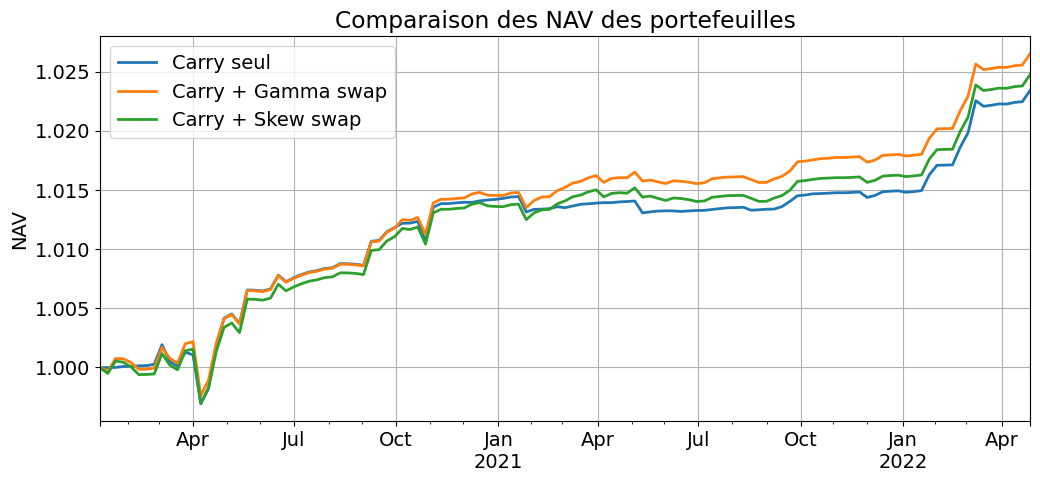

In [140]:
portfolio_nav = (1 + component_returns[
    ["carry_only", "carry_plus_gamma", "carry_plus_skew"]
]).cumprod()

portfolio_nav.head()

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_nav["carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)

ax.set_title("Comparaison des NAV des portefeuilles")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

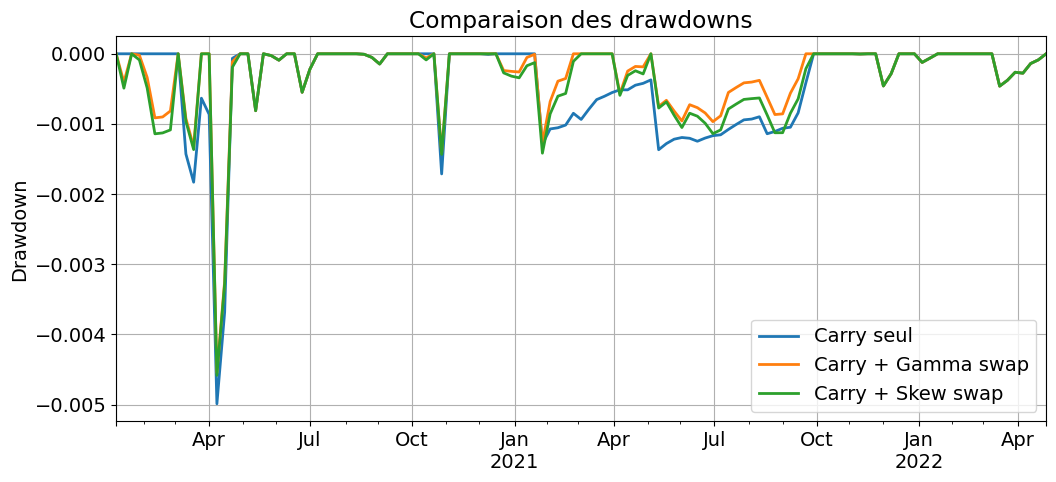

In [141]:
portfolio_drawdowns = portfolio_nav.apply(compute_drawdown)

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_drawdowns["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_drawdowns["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_drawdowns["carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()
plt.show()


In [142]:
def compute_perf_from_nav(nav_series):
    rets = nav_series.pct_change().dropna()
    return {
        "Final NAV": nav_series.iloc[-1],
        "Sharpe": sharpe_ratio(rets),
        "Max Drawdown (%)": 100 * max_drawdown(rets),
        "Calmar": calmar_ratio(rets),
        "Mean daily return": rets.mean(),
        "Daily vol": rets.std(),
    }

portfolio_perf_df = pd.DataFrame({
    "Carry seul": compute_perf_from_nav(portfolio_nav["carry_only"]),
    "Carry + Gamma": compute_perf_from_nav(portfolio_nav["carry_plus_gamma"]),
    "Carry + Skew": compute_perf_from_nav(portfolio_nav["carry_plus_skew"]),
}).T

portfolio_perf_df.round(4)

,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean daily return,Daily vol
Carry seul,1.0234,3.6469,-0.4989,9.7710,0.0002,0.0008
Carry + Gamma,1.0265,4.1064,-0.4546,12.0903,0.0002,0.0008
Carry + Skew,1.0248,3.8355,-0.4584,11.2299,0.0002,0.0008


Le tableau de performance permet d'évaluer si l'ajout du swap améliore ou détériore le profil rendement-risque du carry. Les statistiques clés à surveiller sont le Sharpe ratio, le maximum drawdown et le ratio de Calmar.

In [143]:
corr_components_df = component_returns[
    ["carry", "gamma_scaled", "skew_scaled"]
].corr()

corr_components_df

,carry,gamma_scaled,skew_scaled
carry,1.000000,-0.119427,-0.108684
gamma_scaled,-0.119427,1.000000,0.995411
skew_scaled,-0.108684,0.995411,1.000000


La matrice de corrélation permet de déterminer si les swaps apportent une exposition réellement différente de celle du carry. Une corrélation faible ou négative suggère un potentiel de diversification. Une corrélation positive mais avec une bonne performance en période de stress peut plutôt signaler un rôle de couverture conditionnelle.

In [144]:
stress_threshold = component_returns["carry"].quantile(0.10)
stress_mask = component_returns["carry"] <= stress_threshold

stress_summary = pd.DataFrame({
    "Mean return in carry stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled"
    ]].mean(),
    "Median return in carry stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled"
    ]].median(),
    "Correlation with carry in stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled"
    ]].corr()["carry"],
})

stress_summary

,Mean return in carry stress days,Median return in carry stress days,Correlation with carry in stress days
carry,-0.000987,-0.000549,1.000000
gamma_scaled,0.000324,0.000000,0.390538
skew_scaled,0.000269,0.000000,0.444455


In [145]:
portfolio_stress_summary = pd.DataFrame({
    "Mean return in carry stress days": component_returns.loc[stress_mask, [
        "carry_only", "carry_plus_gamma", "carry_plus_skew"
    ]].mean(),
    "Median return in carry stress days": component_returns.loc[stress_mask, [
        "carry_only", "carry_plus_gamma", "carry_plus_skew"
    ]].median(),
})

portfolio_stress_summary

,Mean return in carry stress days,Median return in carry stress days
carry_only,-0.000987,-0.000549
carry_plus_gamma,-0.000906,-0.000549
carry_plus_skew,-0.000920,-0.000549


Pour mesurer l'effet des swaps lors des phases de stress, on conditionne l'analyse aux pires jours du carry. Cette approche permet de distinguer deux cas :

- si le swap a tendance à performer positivement lorsque le carry souffre, il agit comme une couverture ;
- s'il est surtout faiblement corrélé mais sans protection marquée dans les pires phases, il agit plutôt comme une source de diversification.

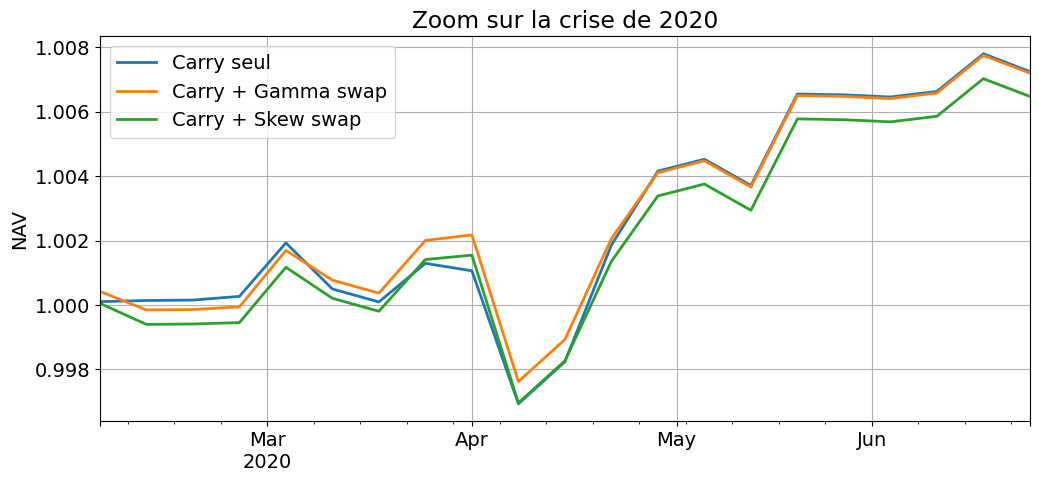

In [146]:
fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)

ax.set_title("Zoom sur la crise de 2020")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

L'analyse de portefeuille permet d'évaluer si les swaps étudiés agissent comme simples diversifiants ou comme instruments de couverture du carry.

La comparaison des NAV et des drawdowns montre si l'ajout du gamma swap ou du skew swap permet de limiter les pertes durant les épisodes de stress. La matrice de corrélation mesure quant à elle le degré de redondance entre les différentes sleeves.

Enfin, l'analyse conditionnelle sur les pires jours du carry est la plus informative : si un swap contribue positivement pendant ces journées, il joue un rôle de hedge. S'il améliore le profil global du portefeuille sans performer spécifiquement pendant les drawdowns, il relève davantage d'une logique de diversification.

## Portefeuille de carry avec ajout de swaps

Afin d'évaluer le rôle potentiel des moment swaps dans une stratégie de trading de volatilité, nous combinons ici une stratégie simple de carry avec différentes sleeves de swaps. Le carry est représenté par un short strangle delta-hedgé sur SPY. Cette stratégie consiste à vendre des options hors-la-monnaie et à capter la prime de volatilité implicite, tout en neutralisant l'exposition directionnelle grâce au delta hedge.

Deux overlays sont ensuite testés :

- un **gamma swap**, qui capte l'évolution de la volatilité réalisée pondérée par le niveau du sous-jacent ;
- un **skew swap**, construit comme combinaison des portefeuilles variance et gamma.

L'objectif est de déterminer si ces swaps agissent comme **source de diversification** ou comme **couverture en période de drawdown**.

### Evolution des NAV

Le premier graphique compare les trajectoires de NAV des trois portefeuilles :

- carry seul
- carry + gamma swap
- carry + skew swap

Les trois stratégies présentent une dynamique très proche, ce qui est attendu étant donné que le carry reste la composante dominante du portefeuille. Toutefois, l'ajout du gamma swap améliore légèrement la performance globale.

Sur l'ensemble de la période étudiée, le portefeuille **carry + gamma swap** atteint la NAV finale la plus élevée. Le portefeuille **carry + skew swap** présente également une amélioration par rapport au carry seul, mais dans une moindre mesure.

Cela suggère que l'ajout d'une exposition au gamma swap apporte une contribution positive au rendement du portefeuille.

### Analyse des drawdowns

Le graphique des drawdowns permet d'observer le comportement du portefeuille durant les périodes de stress.

Le carry seul présente les drawdowns les plus prononcés. Lorsque l'on ajoute le gamma swap ou le skew swap, la profondeur maximale des drawdowns est légèrement réduite.

Cette amélioration reste modeste mais systématique. Les swaps semblent donc contribuer à amortir partiellement les pertes du carry, ce qui est cohérent avec leur exposition aux variations de volatilité réalisée.

### Zoom sur la crise de 2020

Le zoom sur la crise de 2020 permet d'observer plus précisément le comportement des stratégies durant un épisode de stress majeur.

On observe que la chute du portefeuille est légèrement moins prononcée lorsque le gamma swap est ajouté. Le skew swap offre également une amélioration, mais plus faible.

Cette observation est cohérente avec la nature du gamma swap : lorsque la volatilité réalisée augmente fortement, la stratégie peut générer des gains qui compensent partiellement les pertes du carry.

### Statistiques de performance

Les statistiques de performance confirment les observations graphiques.

Le portefeuille carry seul atteint une NAV finale de 1.0234 avec un Sharpe ratio de 3.65. L'ajout du gamma swap améliore ces résultats, avec une NAV finale de 1.0265 et un Sharpe ratio de 4.11.

Le skew swap améliore également la performance par rapport au carry seul, mais dans une moindre mesure.

Les drawdowns maximum sont légèrement réduits lorsque les swaps sont ajoutés. Le gamma swap présente le ratio de Calmar le plus élevé, ce qui indique une meilleure performance ajustée du risque.

### Corrélations entre les composantes

La matrice de corrélation montre que les swaps présentent une corrélation négative modérée avec le carry :

corr(carry, gamma) ≈ -0.12  
corr(carry, skew) ≈ -0.11

Cette corrélation négative indique que les swaps ont tendance à performer lorsque le carry souffre, ce qui est une propriété intéressante dans une logique de diversification.

En revanche, les portefeuilles gamma et skew sont presque parfaitement corrélés entre eux, ce qui est cohérent avec leur construction proche dans notre implémentation empirique.

### Analyse conditionnelle en période de stress

Afin d'évaluer plus précisément le rôle des swaps, nous analysons leurs performances lors des pires journées du carry.

Lorsque le carry subit ses pertes les plus importantes, les swaps affichent en moyenne des rendements positifs. Le gamma swap présente un rendement moyen positif d'environ 0.00032 durant ces périodes.

Cela confirme que les swaps peuvent jouer un rôle de **couverture partielle du carry**, en générant des gains lorsque la stratégie de vente d'options souffre.

## Interprétation

Dans notre implémentation, l'ajout d'un gamma swap améliore légèrement la performance globale du portefeuille et réduit modestement les drawdowns. Le skew swap présente un comportement similaire mais moins marqué.

La corrélation négative avec le carry et les performances positives observées durant les périodes de stress suggèrent que ces swaps agissent principalement comme des **instruments de couverture partielle**, plutôt que comme une simple source de diversification.

Toutefois, l'amélioration reste modérée, ce qui s'explique par la forte similarité entre les portefeuilles de swaps dans notre implémentation empirique.

## Extension : carry avec overlay de kurtosis

En complément des overlays gamma et skew, on ajoute une sleeve fondée sur le moment réalisé d'ordre 4. Cette brique ne correspond pas ici à une réplication statique complète d'un kurtosis swap par options vanilles, mais à une proxy empirique du risque de queue construite à partir des log-returns réalisés.

L'objectif est d'évaluer si une exposition au kurtosis apporte une protection supplémentaire au portefeuille de carry en période de stress, en comparaison des overlays gamma et skew.

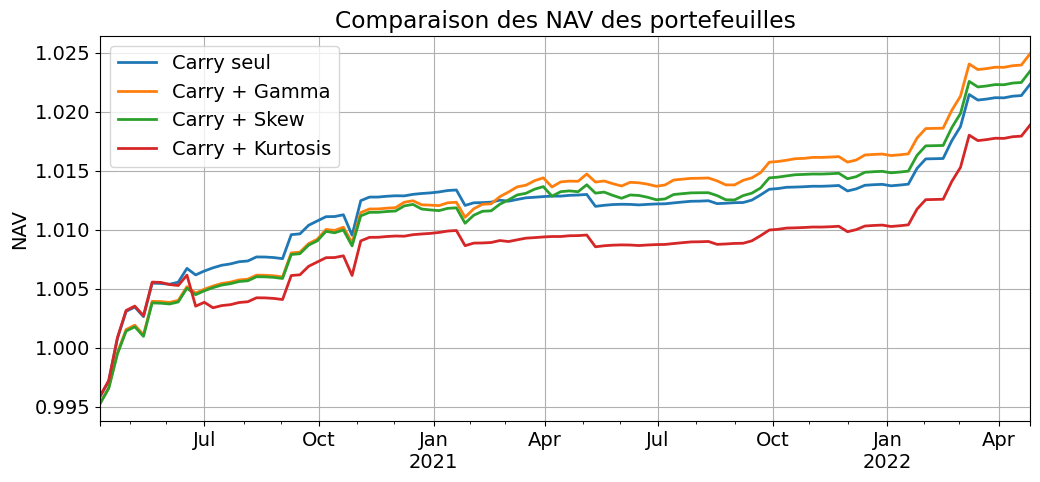

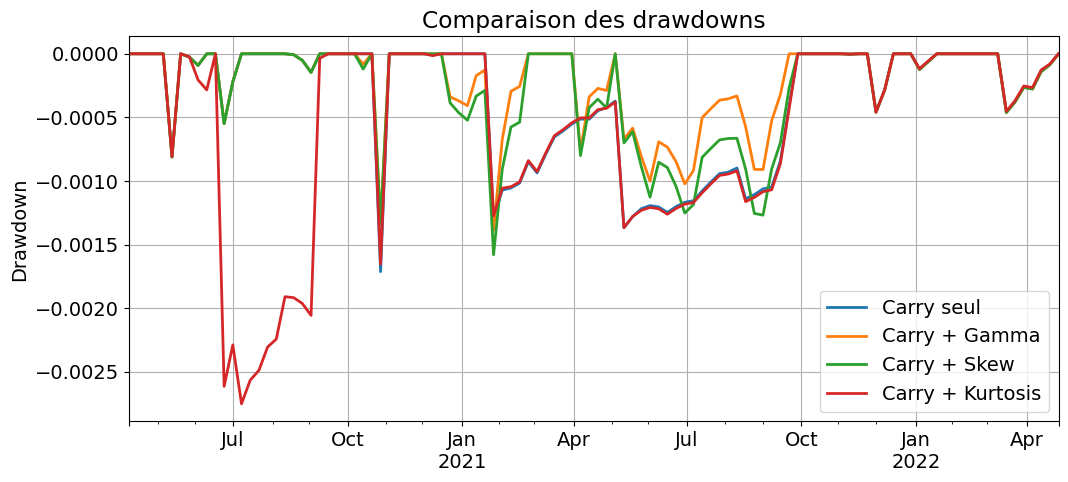

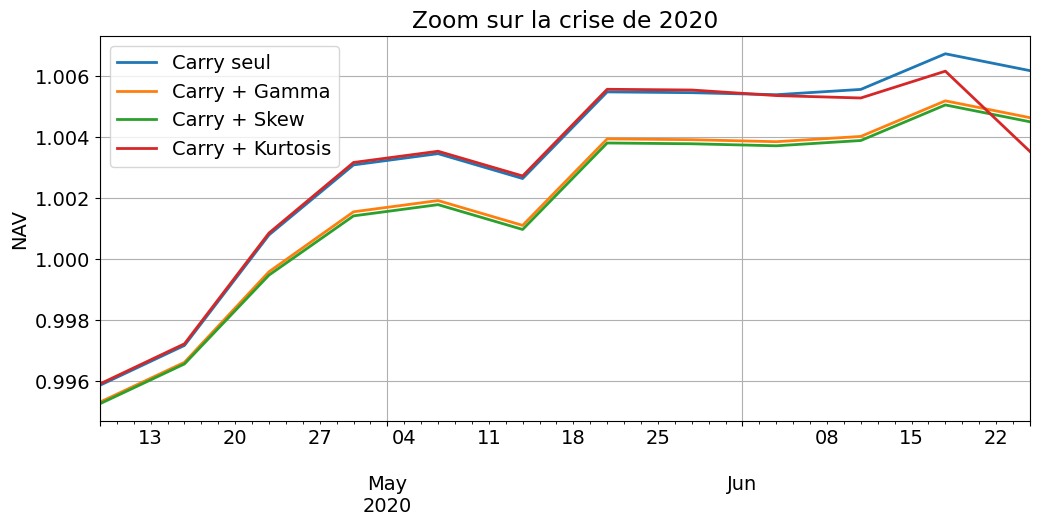

In [147]:
kurtosis_overlay = kurt_3m.set_index("date").iloc[:, 0].diff().dropna()
kurtosis_overlay.name = "kurtosis"

component_returns_extended = pd.concat(
    [
        rets_carry.rename("carry"),
        rets_gamma_custom.rename("gamma"),
        rets_skew_custom.rename("skew"),
        kurtosis_overlay.rename("kurtosis"),
    ],
    axis=1
).dropna()

component_returns_extended.head()

target_vol = component_returns_extended["carry"].std()

gamma_scale = target_vol / component_returns_extended["gamma"].std()
skew_scale = target_vol / component_returns_extended["skew"].std()
kurtosis_scale = target_vol / component_returns_extended["kurtosis"].std()

component_returns_extended["gamma_scaled"] = component_returns_extended["gamma"] * gamma_scale
component_returns_extended["skew_scaled"] = component_returns_extended["skew"] * skew_scale
component_returns_extended["kurtosis_scaled"] = component_returns_extended["kurtosis"] * kurtosis_scale

alpha = 0.25

component_returns_extended["carry_only"] = component_returns_extended["carry"]
component_returns_extended["carry_plus_gamma"] = (
    component_returns_extended["carry"] + alpha * component_returns_extended["gamma_scaled"]
)
component_returns_extended["carry_plus_skew"] = (
    component_returns_extended["carry"] + alpha * component_returns_extended["skew_scaled"]
)
component_returns_extended["carry_plus_kurtosis"] = (
    component_returns_extended["carry"] + alpha * component_returns_extended["kurtosis_scaled"]
)

portfolio_nav_ext = (1 + component_returns_extended[
    ["carry_only", "carry_plus_gamma", "carry_plus_skew", "carry_plus_kurtosis"]
]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav_ext["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav_ext["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma", lw=2)
portfolio_nav_ext["carry_plus_skew"].plot(ax=ax, label="Carry + Skew", lw=2)
portfolio_nav_ext["carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis", lw=2)

ax.set_title("Comparaison des NAV des portefeuilles")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

portfolio_drawdowns_ext = portfolio_nav_ext.apply(compute_drawdown)

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_drawdowns_ext["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_drawdowns_ext["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma", lw=2)
portfolio_drawdowns_ext["carry_plus_skew"].plot(ax=ax, label="Carry + Skew", lw=2)
portfolio_drawdowns_ext["carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()
plt.show()

portfolio_perf_ext_df = pd.DataFrame({
    "Carry seul": compute_perf_from_nav(portfolio_nav_ext["carry_only"]),
    "Carry + Gamma": compute_perf_from_nav(portfolio_nav_ext["carry_plus_gamma"]),
    "Carry + Skew": compute_perf_from_nav(portfolio_nav_ext["carry_plus_skew"]),
    "Carry + Kurtosis": compute_perf_from_nav(portfolio_nav_ext["carry_plus_kurtosis"]),
}).T

portfolio_perf_ext_df.round(4)

corr_components_ext_df = component_returns_extended[
    ["carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"]
].corr()

corr_components_ext_df

stress_threshold_ext = component_returns_extended["carry"].quantile(0.10)
stress_mask_ext = component_returns_extended["carry"] <= stress_threshold_ext

stress_summary_ext = pd.DataFrame({
    "Mean return in carry stress days": component_returns_extended.loc[stress_mask_ext, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].mean(),
    "Median return in carry stress days": component_returns_extended.loc[stress_mask_ext, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].median(),
    "Correlation with carry in stress days": component_returns_extended.loc[stress_mask_ext, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].corr()["carry"],
})

stress_summary_ext

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav_ext.loc["2020-02-01":"2020-06-30", "carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav_ext.loc["2020-02-01":"2020-06-30", "carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma", lw=2)
portfolio_nav_ext.loc["2020-02-01":"2020-06-30", "carry_plus_skew"].plot(ax=ax, label="Carry + Skew", lw=2)
portfolio_nav_ext.loc["2020-02-01":"2020-06-30", "carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis", lw=2)

ax.set_title("Zoom sur la crise de 2020")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()
plt.show()

## Extension : ajout d’un overlay de kurtosis au portefeuille de carry

En complément des overlays gamma et skew, nous introduisons une exposition supplémentaire basée sur le moment réalisé d’ordre 4, c’est-à-dire le **kurtosis réalisé**. L’objectif est d’évaluer si une exposition au risque de queue peut améliorer le comportement du portefeuille de carry, notamment lors des épisodes de stress de marché.

Contrairement aux gamma et skew swaps, qui sont répliqués par des portefeuilles d’options, l’exposition au kurtosis est ici approchée empiriquement à partir de la variation du kurtosis réalisé calculé sur une fenêtre glissante de trois mois. Cette mesure permet de capturer les périodes où la distribution des rendements devient plus leptokurtique, c’est-à-dire lorsque la probabilité d’événements extrêmes augmente.


Analyse des NAV

Le premier graphique compare l’évolution de la valeur liquidative (NAV) de quatre portefeuilles :

Carry seul

Carry + Gamma swap

Carry + Skew swap

Carry + Kurtosis

Observation principale :

Le portefeuille carry + gamma swap obtient la meilleure performance globale.

Le portefeuille carry + skew swap améliore légèrement la performance par rapport au carry seul.

Le portefeuille carry + kurtosis présente une performance inférieure aux autres stratégies.

Cela suggère que l’exposition au kurtosis ne contribue pas positivement au rendement moyen dans cette implémentation.

Une explication possible est que la variation du kurtosis réalisé est beaucoup plus bruitée et moins persistante que les composantes de volatilité capturées par les gamma et skew swaps. Par conséquent, son apport au portefeuille est plus instable.

Analyse des drawdowns

Le second graphique compare les drawdowns des différentes stratégies.

Les résultats montrent que :

Les overlays gamma et skew réduisent légèrement la profondeur des drawdowns du portefeuille de carry.

Le portefeuille carry + kurtosis présente des drawdowns plus irréguliers et parfois plus marqués.

En particulier, certaines périodes montrent des chutes plus abruptes pour le portefeuille incluant le kurtosis, ce qui indique que cette exposition peut introduire davantage de volatilité dans la performance du portefeuille.

Cela confirme que le kurtosis overlay agit davantage comme une source de bruit que comme une couverture efficace.

Analyse de la crise de 2020

Le zoom sur la période de la crise du COVID-19 permet d’observer plus précisément le comportement des différentes stratégies pendant un épisode de stress extrême.

Durant cette période :

Les portefeuilles carry + gamma et carry + skew suivent une trajectoire similaire et bénéficient légèrement de l’augmentation de la volatilité réalisée.

Le portefeuille carry + kurtosis ne montre pas d’amélioration significative et reste proche du carry seul.

Cela suggère que l’exposition au kurtosis réalisée ne capture pas efficacement la dynamique des épisodes de volatilité extrême dans cette implémentation.

Interprétation économique

Ces résultats permettent de tirer plusieurs conclusions importantes.

Les gamma swaps semblent constituer la meilleure extension du portefeuille de carry. Leur performance s’explique par leur sensibilité à l’augmentation de la volatilité réalisée, qui tend à se produire lorsque les stratégies de vente d’options souffrent.

Les skew swaps présentent un comportement similaire mais légèrement moins performant. Cela est cohérent avec leur construction, qui combine les expositions variance et gamma.

En revanche, l’overlay basé sur le kurtosis réalisé n’apporte pas d’amélioration significative. Cela peut s’expliquer par plusieurs raisons :

la mesure empirique du kurtosis est très instable ;

la variation du kurtosis réalisé ne correspond pas directement à la prime de kurtosis implicite présente dans les options ;

l’exposition obtenue n’est pas directement répliquée par des portefeuilles d’options, contrairement aux variance et gamma swaps.

Conclusion sur les overlays

Dans l’ensemble, les résultats suggèrent que les swaps basés sur les moments de la distribution des rendements peuvent jouer des rôles différents dans un portefeuille de volatilité.

Les gamma swaps apparaissent comme l’overlay le plus efficace pour améliorer le couple rendement-risque du carry.

Les skew swaps offrent également un certain degré de diversification, bien que leur contribution reste modérée.

En revanche, l’overlay basé sur le kurtosis réalisé ne semble pas constituer une source de diversification ou de couverture efficace dans cette implémentation empirique.

Ces résultats confirment que les moments d’ordre deux et trois de la distribution des rendements (variance et skew) sont généralement plus exploitables dans les marchés d’options que les moments d’ordre supérieur.